# SAM3 Object Detector Integration Test

This notebook tests the SAM3 text-based object detection integration and validates that outputs match the expected format for `crops_to_json.py`.

## Setup

Install SAM3 if not already installed:
```bash
pip install 'git+https://github.com/facebookresearch/sam3.git'
```

In [1]:
import sys
import os
from pathlib import Path

# Add repo root to path
repo_root = str(Path(os.getcwd()).parent)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

print(f"Python executable: {sys.executable}")
print(f"Repo root: {repo_root}")

Python executable: /mnt/abka03/.conda/envs/xlvlm-v1/bin/python
Repo root: /mnt/abka03/Projects/xl-vlm-api/xl-vlms


In [2]:
# Check if SAM3 is available
try:
    import sam3
    print(f"SAM3 version: {sam3.__version__ if hasattr(sam3, '__version__') else 'unknown'}")
    SAM3_AVAILABLE = True
except ImportError as e:
    print(f"SAM3 not installed: {e}")
    print("Install with: pip install 'git+https://github.com/facebookresearch/sam3.git'")
    SAM3_AVAILABLE = False
except Exception as e:
    print(f"SAM3 import error: {type(e).__name__}: {e}")
    SAM3_AVAILABLE = False

# Check if LangSAM is available
try:
    from lang_sam import LangSAM
    print("LangSAM available")
    LANGSAM_AVAILABLE = True
except ImportError:
    print("LangSAM not installed")
    LANGSAM_AVAILABLE = False

/mnt/abka03/.conda/envs/xlvlm-v1/lib/python3.10/site-packages/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/mnt/abka03/.conda/envs/xlvlm-v1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SAM3 version: 0.1.0
LangSAM available


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.1+cu126
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3090


## Load Test Images

Use sample images from the repo or create test images.

In [4]:
# Find test images in the repo
test_image_dirs = [
    os.path.join(repo_root, "data", "train"),
    os.path.join(repo_root, "data", "val"),
    os.path.join(repo_root, "readme_samples", "images"),
]

test_images = []
for d in test_image_dirs:
    if os.path.isdir(d):
        for root, _, files in os.walk(d):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    test_images.append(os.path.join(root, f))
            if len(test_images) >= 5:
                break
    if len(test_images) >= 5:
        break

print(f"Found {len(test_images)} test images")
for img in test_images[:5]:
    print(f"  - {img}")

Found 30 test images
  - /mnt/abka03/Projects/xl-vlm-api/xl-vlms/data/train/orange/120447.jpg
  - /mnt/abka03/Projects/xl-vlm-api/xl-vlms/data/train/orange/454258.jpg
  - /mnt/abka03/Projects/xl-vlm-api/xl-vlms/data/train/orange/151694.jpg
  - /mnt/abka03/Projects/xl-vlm-api/xl-vlms/data/train/orange/119923.jpg
  - /mnt/abka03/Projects/xl-vlm-api/xl-vlms/data/train/orange/104568.jpg


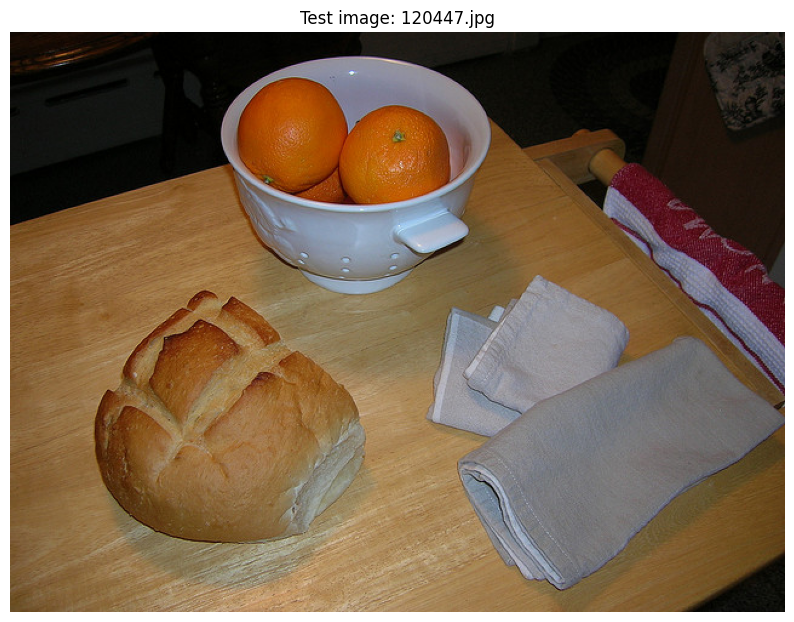

Image size: (640, 479)


In [5]:
# If no images found, create a simple test image
if not test_images:
    print("Creating a simple test image...")
    # Create a simple image with colored shapes
    img = Image.new('RGB', (640, 480), color='white')
    from PIL import ImageDraw
    draw = ImageDraw.Draw(img)
    # Draw some colored rectangles
    draw.rectangle([50, 50, 150, 150], fill='red')
    draw.rectangle([200, 100, 350, 250], fill='blue')
    draw.ellipse([400, 150, 550, 300], fill='green')
    
    test_img_path = os.path.join(repo_root, "temp", "test_image.png")
    os.makedirs(os.path.dirname(test_img_path), exist_ok=True)
    img.save(test_img_path)
    test_images = [test_img_path]
    print(f"Created test image: {test_img_path}")

# Display first test image
if test_images:
    img = Image.open(test_images[0])
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Test image: {os.path.basename(test_images[0])}")
    plt.axis('off')
    plt.show()
    print(f"Image size: {img.size}")

## Test SAM3 Utilities

In [6]:
if SAM3_AVAILABLE:
    from src.sam3_utils import load_sam3, predict_bboxes_for_tag_sam3
    
    print("Loading SAM3 model...")
    sam3_model = load_sam3(device="cuda" if torch.cuda.is_available() else "cpu")
    print("SAM3 model loaded successfully!")
else:
    print("Skipping SAM3 test - not installed")
    sam3_model = None

Loading SAM3 model...
SAM3 model loaded successfully!


In [ ]:
def visualize_bboxes(image_path, bboxes, title="Detections"):
    """Visualize bounding boxes on an image.
    
    Args:
        image_path: Path to the image.
        bboxes: List of [x, y, w, h] boxes.
        title: Plot title.
    """
    img = Image.open(image_path)
    fig, ax = plt.subplots(1, figsize=(12, 10))
    ax.imshow(img)
    
    colors = plt.cm.tab10.colors
    for i, (x, y, w, h) in enumerate(bboxes):
        color = colors[i % len(colors)]
        rect = mpatches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x, y - 5, f"Box {i+1}", color=color, fontsize=10, fontweight='bold')
    
    ax.set_title(f"{title} ({len(bboxes)} boxes)")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Test SAM3 detection with a text prompt
if sam3_model and test_images:
    test_prompts = ["object", "person", "animal", "car"]
    
    for prompt in test_prompts:
        print(f"\nTesting prompt: '{prompt}'")
        try:
            results = predict_bboxes_for_tag_sam3(
                sam3_model,
                test_images[:1],
                tag=prompt,
                topn=5
            )
            
            bboxes = results[0]
            print(f"  Found {len(bboxes)} boxes")
            for i, box in enumerate(bboxes):
                print(f"    Box {i+1}: x={box[0]}, y={box[1]}, w={box[2]}, h={box[3]}")
            
            if bboxes:
                visualize_bboxes(test_images[0], bboxes, title=f"SAM3: '{prompt}'")
                break  # Show first successful detection
        except Exception as e:
            print(f"  Error: {e}")

## Test LangSAM for Comparison

In [ ]:
if LANGSAM_AVAILABLE:
    from src.langsam_utils import load_langsam, predict_bboxes_for_tag
    
    print("Loading LangSAM model...")
    langsam_model = load_langsam(device="cuda" if torch.cuda.is_available() else "cpu")
    print("LangSAM model loaded successfully!")
else:
    print("Skipping LangSAM test - not installed")
    langsam_model = None

In [ ]:
# Test LangSAM detection
if langsam_model and test_images:
    test_prompts = ["object", "person", "animal", "car"]
    
    for prompt in test_prompts:
        print(f"\nTesting prompt: '{prompt}'")
        try:
            results = predict_bboxes_for_tag(
                langsam_model,
                test_images[:1],
                tag=prompt
            )
            
            bboxes = results[0]
            print(f"  Found {len(bboxes)} boxes")
            for i, box in enumerate(bboxes[:5]):
                print(f"    Box {i+1}: x={box[0]}, y={box[1]}, w={box[2]}, h={box[3]}")
            
            if bboxes:
                visualize_bboxes(test_images[0], bboxes[:5], title=f"LangSAM: '{prompt}'")
                break  # Show first successful detection
        except Exception as e:
            print(f"  Error: {e}")

## Validate Output Format

Ensure SAM3 output matches the expected format for `crops_to_json.py`:
- List of images -> List of boxes per image
- Each box is `[x, y, w, h]` as integers
- Boxes are clamped to image bounds

In [ ]:
def validate_bbox_format(bboxes, image_path):
    """Validate that bboxes match expected format."""
    img = Image.open(image_path)
    W, H = img.size
    
    print(f"Image size: {W}x{H}")
    print(f"Number of boxes: {len(bboxes)}")
    
    all_valid = True
    for i, box in enumerate(bboxes):
        # Check format
        if not isinstance(box, (list, tuple)) or len(box) != 4:
            print(f"  Box {i}: INVALID - not a 4-element list/tuple")
            all_valid = False
            continue
        
        x, y, w, h = box
        
        # Check types
        if not all(isinstance(v, (int, np.integer)) for v in [x, y, w, h]):
            print(f"  Box {i}: WARNING - not all integers: {[type(v).__name__ for v in [x, y, w, h]]}")
        
        # Check bounds
        if x < 0 or y < 0:
            print(f"  Box {i}: WARNING - negative coordinates: x={x}, y={y}")
        if x + w > W or y + h > H:
            print(f"  Box {i}: WARNING - exceeds image bounds: x+w={x+w} > {W} or y+h={y+h} > {H}")
        if w <= 0 or h <= 0:
            print(f"  Box {i}: WARNING - non-positive dimensions: w={w}, h={h}")
        
        print(f"  Box {i}: x={x}, y={y}, w={w}, h={h} - OK")
    
    return all_valid

In [ ]:
# Validate SAM3 output format
if sam3_model and test_images:
    print("=" * 50)
    print("Validating SAM3 output format")
    print("=" * 50)
    
    results = predict_bboxes_for_tag_sam3(
        sam3_model,
        test_images[:1],
        tag="object",
        topn=10
    )
    
    # Check return structure
    print(f"\nReturn type: {type(results)}")
    print(f"Length matches input: {len(results) == 1}")
    print(f"Inner type: {type(results[0])}")
    
    if results[0]:
        print(f"\nValidating boxes:")
        validate_bbox_format(results[0], test_images[0])

## Test `run_detector_batched` from crops_to_json

In [ ]:
# Test the unified detector interface
from preprocessing.crops_to_json import run_detector_batched

if test_images:
    print("Testing run_detector_batched with SAM3...")
    try:
        results = run_detector_batched(
            test_images[:2],
            tag="object",
            detector="sam3",
            batch_size=1,
            topn=5
        )
        print(f"SAM3 detector returned {len(results)} results")
        for i, boxes in enumerate(results):
            print(f"  Image {i}: {len(boxes)} boxes")
    except Exception as e:
        print(f"SAM3 error: {e}")
    
    print("\nTesting run_detector_batched with LangSAM...")
    try:
        results = run_detector_batched(
            test_images[:2],
            tag="object",
            detector="langsam",
            batch_size=1,
            topn=5
        )
        print(f"LangSAM detector returned {len(results)} results")
        for i, boxes in enumerate(results):
            print(f"  Image {i}: {len(boxes)} boxes")
    except Exception as e:
        print(f"LangSAM error: {e}")

## Test CLI Arguments

Test that the CLI accepts the new `--object_detector` argument.

In [ ]:
# Test CLI argument parsing
import subprocess

print("Testing CLI help...")
result = subprocess.run(
    ["python", os.path.join(repo_root, "preprocessing", "crops_to_json.py"), "--help"],
    capture_output=True,
    text=True
)
print(result.stdout)

# Check that --object_detector is in the help
if "--object_detector" in result.stdout:
    print("✓ --object_detector argument is available")
else:
    print("✗ --object_detector argument NOT found")

# Check choices
if "langsam" in result.stdout and "sam3" in result.stdout:
    print("✓ Both 'langsam' and 'sam3' choices are available")

## Summary

This notebook validates:
1. SAM3 utilities load and run correctly
2. Output format matches expected `[x, y, w, h]` integer boxes
3. Boxes are clamped to image bounds
4. The unified `run_detector_batched` interface works for both backends
5. CLI accepts `--object_detector {none,langsam,sam3}`

In [ ]:
print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"SAM3 available: {SAM3_AVAILABLE}")
print(f"LangSAM available: {LANGSAM_AVAILABLE}")
print(f"Test images found: {len(test_images)}")
print("\nTo use SAM3 with crops_to_json.py:")
print("  python preprocessing/crops_to_json.py --input_root ./data/train --output_json output.json --object_detector sam3")
print("\nTo use LangSAM (legacy):")
print("  python preprocessing/crops_to_json.py --input_root ./data/train --output_json output.json --object_detector langsam")
print("  # or with legacy flag:")
print("  python preprocessing/crops_to_json.py --input_root ./data/train --output_json output.json --object_detection")